In [ ]:
from scripts.utils.utils import *
from scripts.preprocessing.preprocessing import *
from scripts.preprocessing.data_loader import ThermalDataset

import numpy as np
import os 
from dotenv import load_dotenv
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import random

In [ ]:
load_dotenv()
BASE_DIR = Path(os.getenv("BASE_DIR"))
data_path = BASE_DIR / "data"
#masks_merger(data_path)

In [8]:
images_dir = os.path.join(data_path, "images")
masks_dir = os.path.join(data_path, "mask_merged")
print("Images directory: ", images_dir, " Masks directory: ", masks_dir)

dataset = ThermalDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    height=256, 
    width=384,
    multiclass=True,
)
print("Number of images: ", len(dataset))

Images directory:  ../BCXTT/data/images  Masks directory:  ../BCXTT/data/mask_merged
Number of images:  244


In [ ]:
print("Images dtype: ", dataset[0][0].dtype)
print("Masks dtype: ", dataset[0][1].dtype)

Images dtype:  torch.float32
Masks dtype:  torch.int64


## Imbalanceness Analysis

In [ ]:
labels_distribution = []
for i in range(len(dataset)):
    image, mask = dataset[i]
    mask = mask.numpy()
    mask = mask.astype(np.uint8)
    mask = np.squeeze(mask)
    mask_counts = np.unique(mask, return_counts=True)
    labels_distribution.append(mask_counts[1])

[80023  9488  8793]
[70151 14677 13476]
[73353 13178 11773]
[78431 10230  9643]
[65782 16337 16185]
[86973  5398  5933]
[91888  3477  2939]
[88091  4719  5494]
[69314 13486 15504]
[85930  6070  6304]
[82528  8463  7313]
[75772 10937 11595]
[79782  9354  9168]
[82693  7924  7687]
[86557  5314  6433]
[81609  8243  8452]
[76907  9846 11551]
[71723 13869 12712]
[82734  8407  7163]
[80557  8686  9061]
[95663  1329  1312]
[90605  3894  3805]
[71401 14031 12872]
[81520  8102  8682]
[80122  9017  9165]
[74670 11395 12239]
[84214  7042  7048]
[89116  4439  4749]
[88980  4574  4750]
[63996 18619 15689]
[89373  4276  4655]
[83255  7524  7525]
[83228  6824  8252]
[58202 20087 20015]
[77641 10762  9901]
[93003  2772  2529]
[80856  8588  8860]
[71781 13891 12632]
[92482  3212  2610]
[71303 13487 13514]
[93791  2222  2291]
[92404  3086  2814]
[79822  9395  9087]
[81632  7917  8755]
[75311 10588 12405]
[79874  8883  9547]
[82242  7425  8637]
[77793 11065  9446]
[76775 10408 11121]
[80828  7121 10355]


In [20]:
total_number_of_pixels_per_class = np.sum(labels_distribution, axis=0)
total_number_of_pixels = np.sum(total_number_of_pixels_per_class)
print("Total number of pixels: ", total_number_of_pixels, " Total number of pixels per class: ", total_number_of_pixels_per_class)

frequency_per_class = total_number_of_pixels_per_class / total_number_of_pixels
print("Frequency per class: ", frequency_per_class)

weights_per_class = 1 / frequency_per_class
weights_per_class = weights_per_class / np.sum(weights_per_class)
print("Weights per class: ", weights_per_class)

Total number of pixels:  23986176  Total number of pixels per class:  [19947254  1950966  2087956]
Frequency per class:  [0.83161459 0.0813371  0.08704831]
Weights per class:  [0.04812834 0.49207837 0.45979329]


(244, 3)


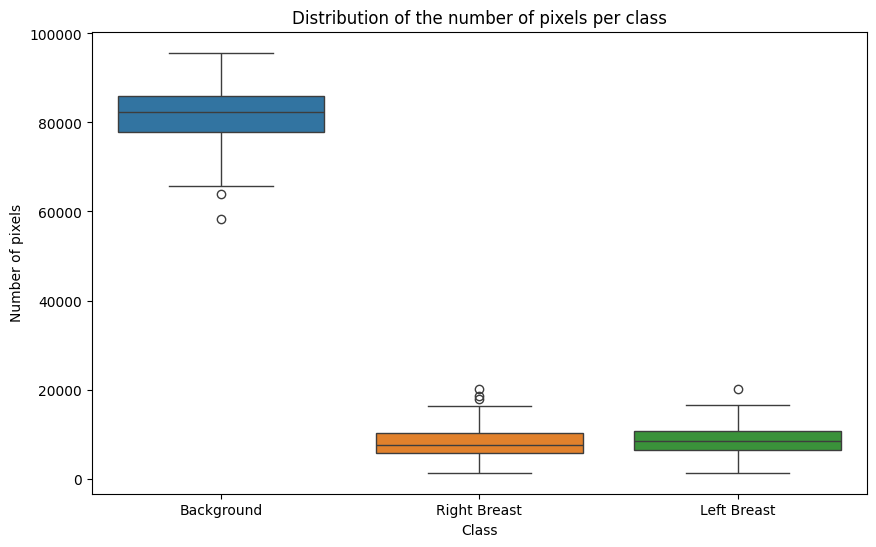

In [ ]:
labels_distribution = np.array(labels_distribution)
print(labels_distribution.shape)

plt.figure(figsize=(10, 6))
sns.boxplot(data=labels_distribution)
plt.title("Distribution of the number of pixels per class")
plt.xlabel("Class")
plt.ylabel("Number of pixels")
plt.xticks(ticks=[0, 1, 2], labels=["Background", "Right Breast", "Left Breast"])
plt.show()

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  0.99607843
Mask unique values:  [0. 1.]


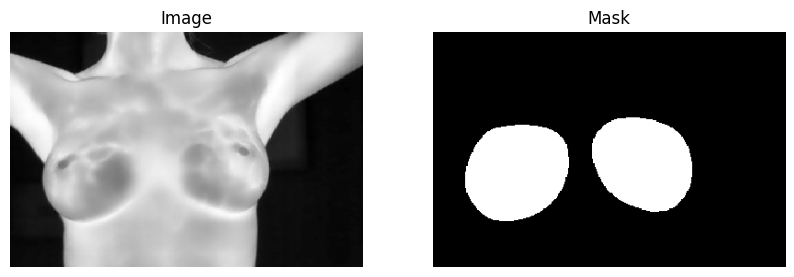

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


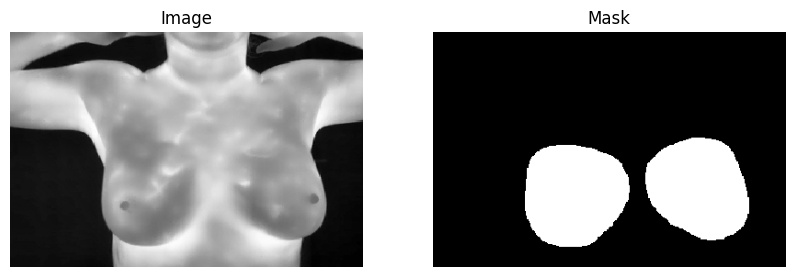

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


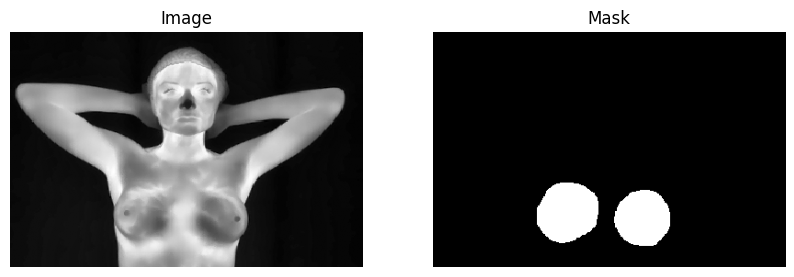

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


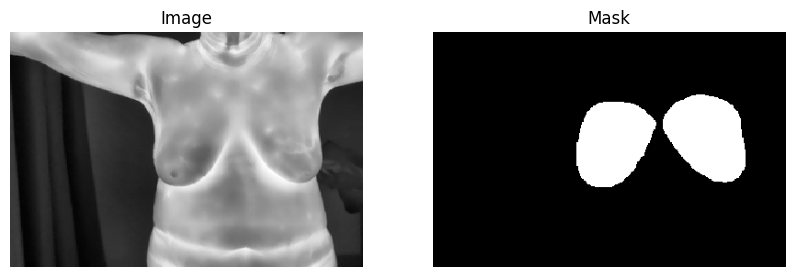

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


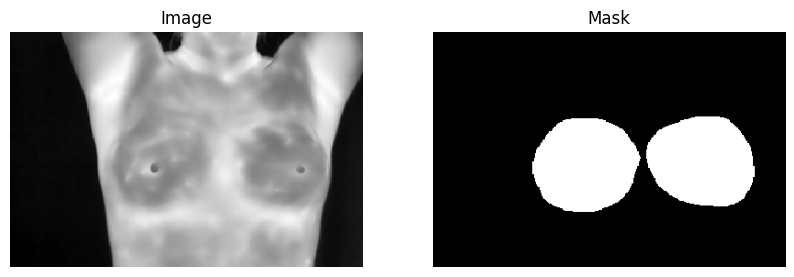

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


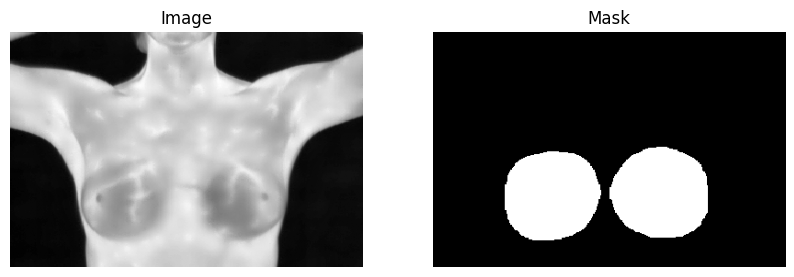

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


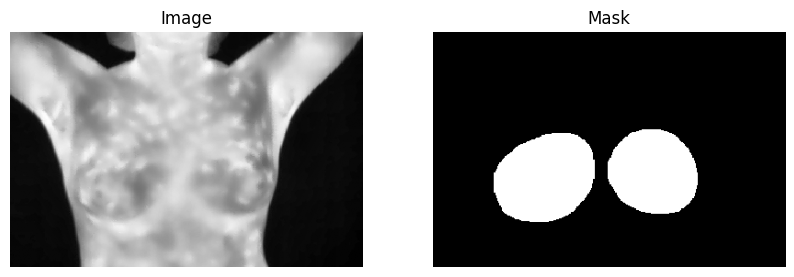

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


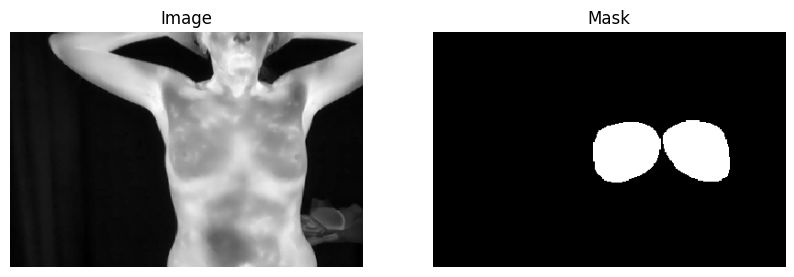

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.011764706
Image max:  1.0
Mask unique values:  [0. 1.]


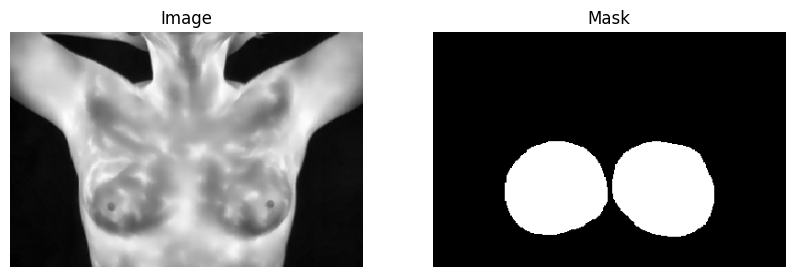

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


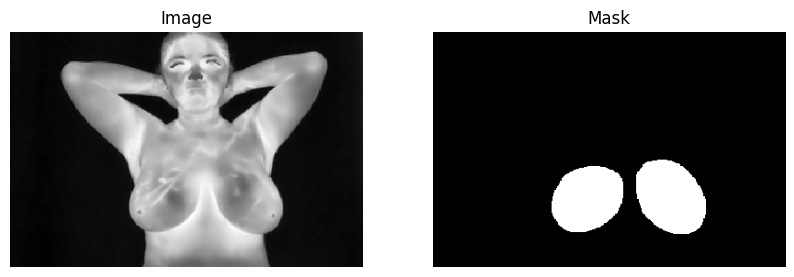

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


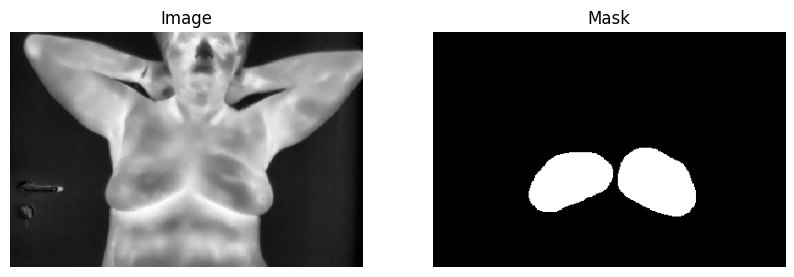

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


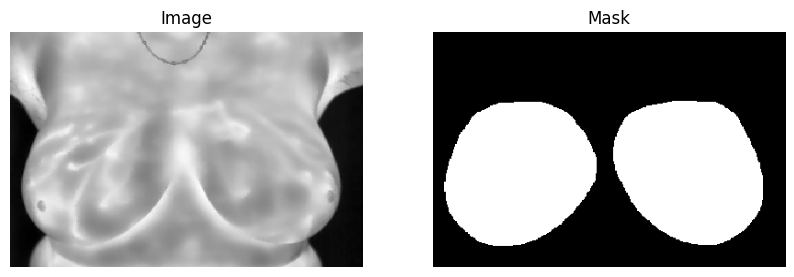

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


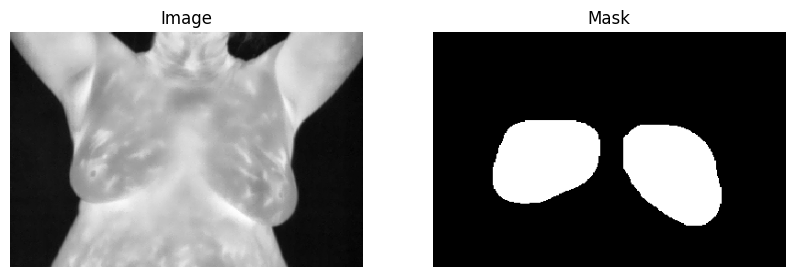

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


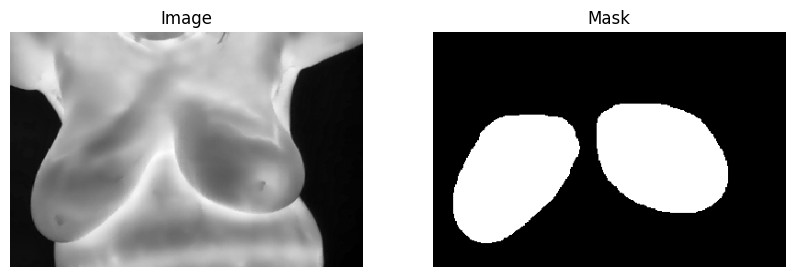

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


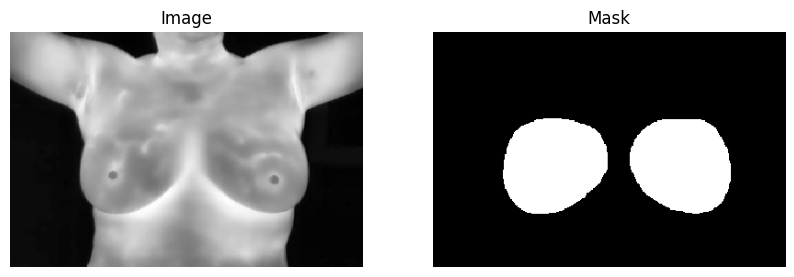

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


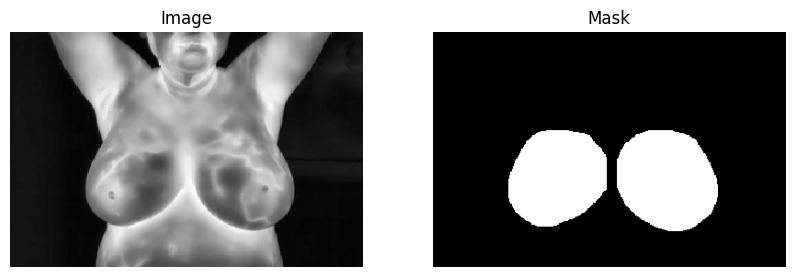

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


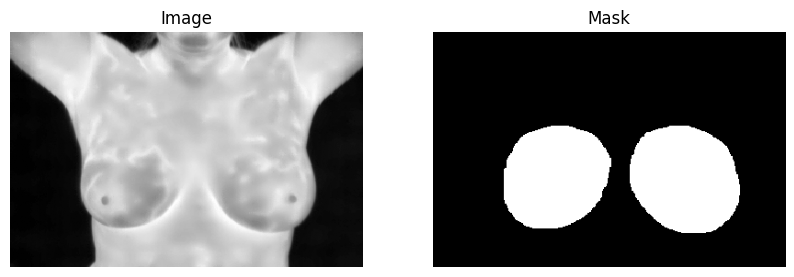

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  0.99607843
Mask unique values:  [0. 1.]


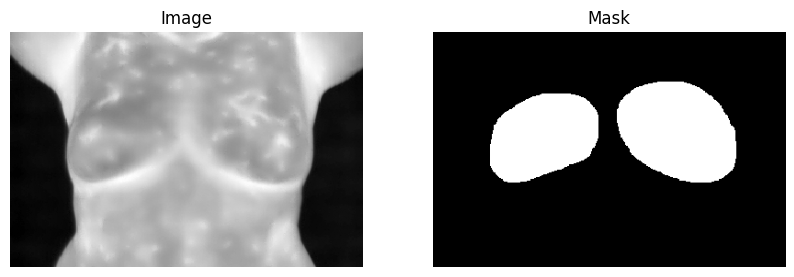

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


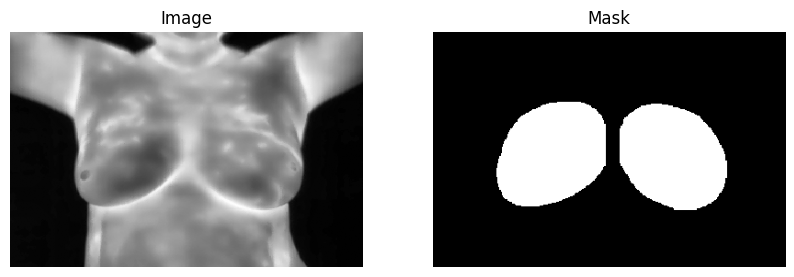

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


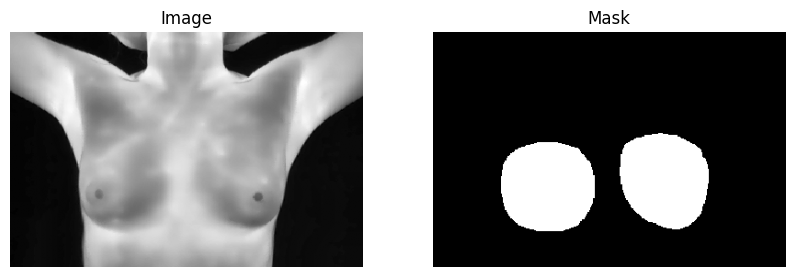

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


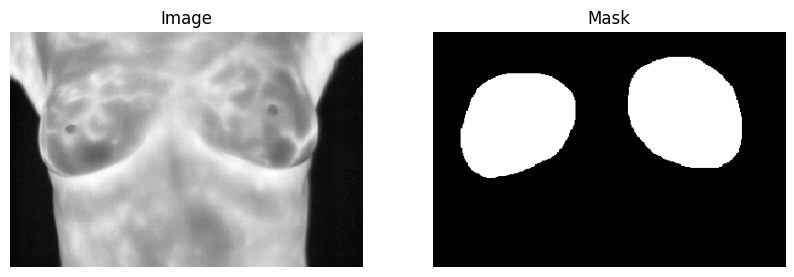

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


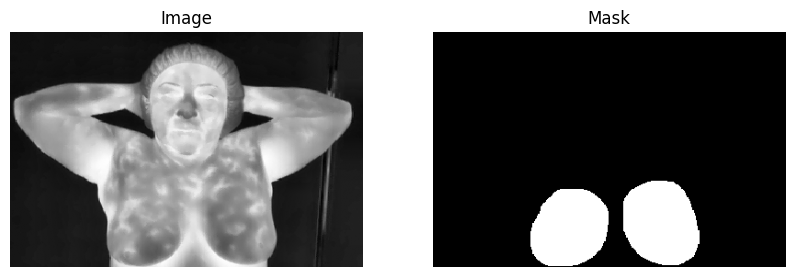

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


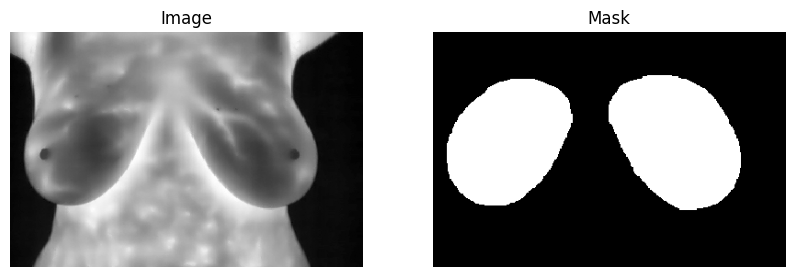

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


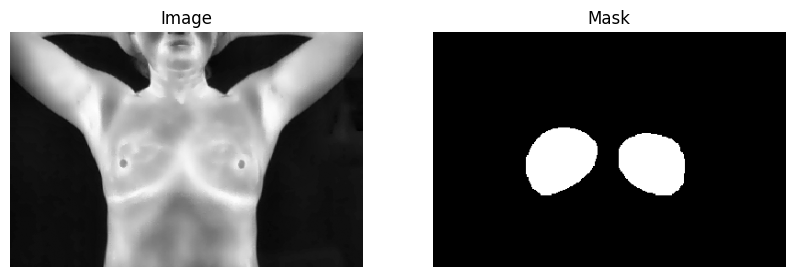

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


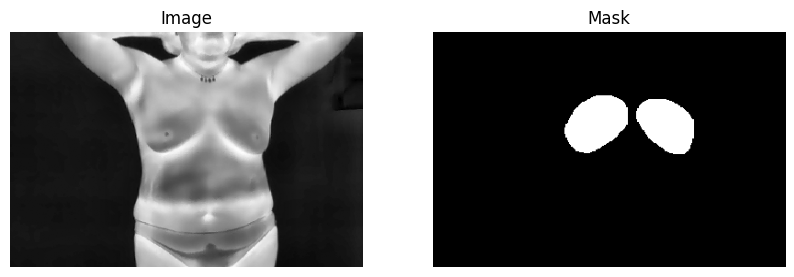

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


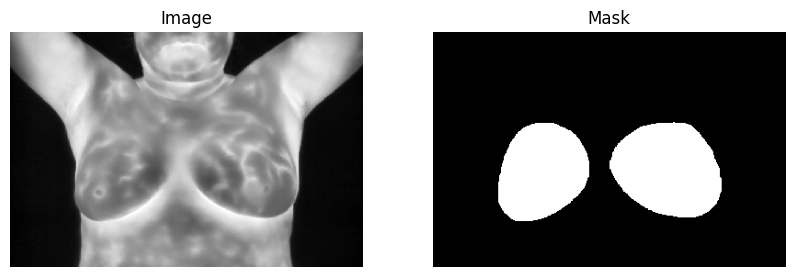

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


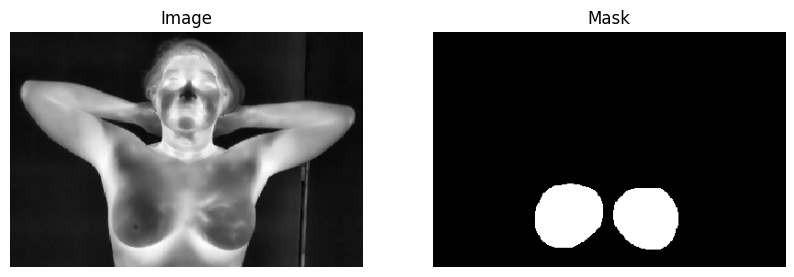

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  0.99607843
Mask unique values:  [0. 1.]


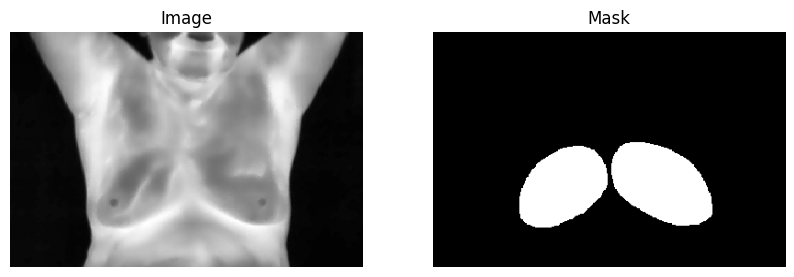

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


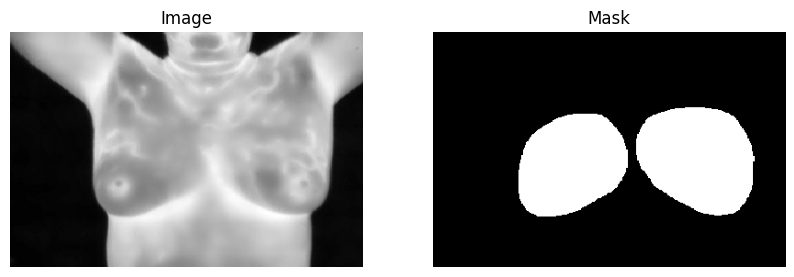

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


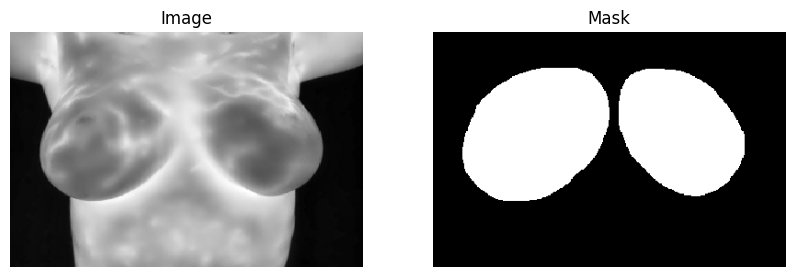

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


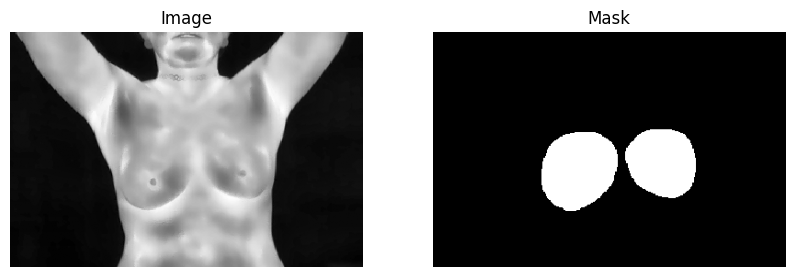

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


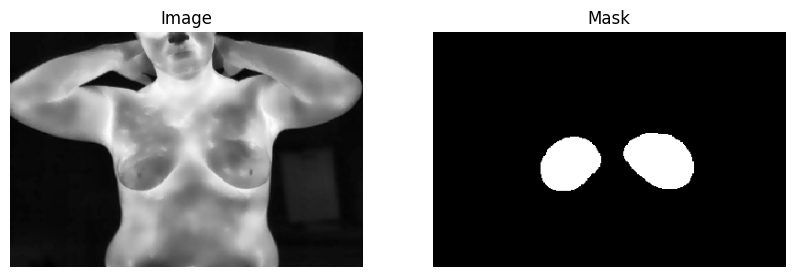

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


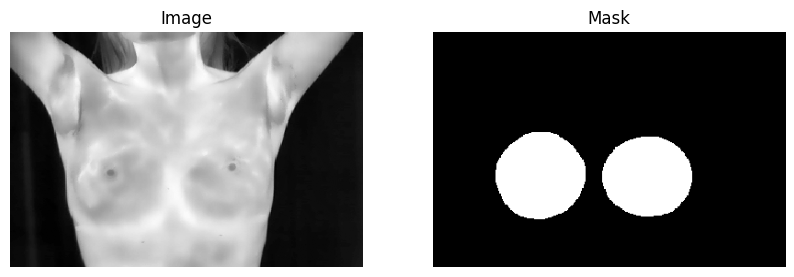

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


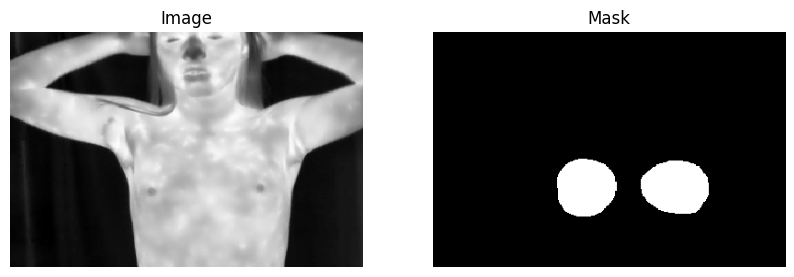

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  0.99607843
Mask unique values:  [0. 1.]


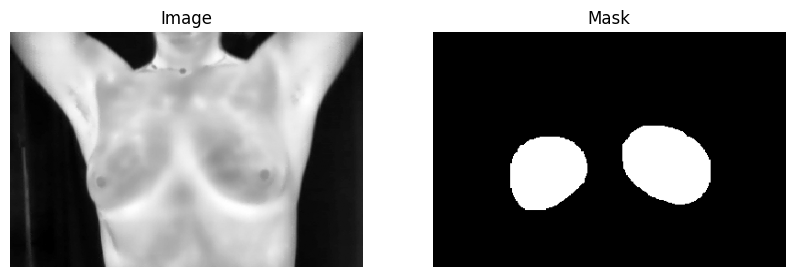

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


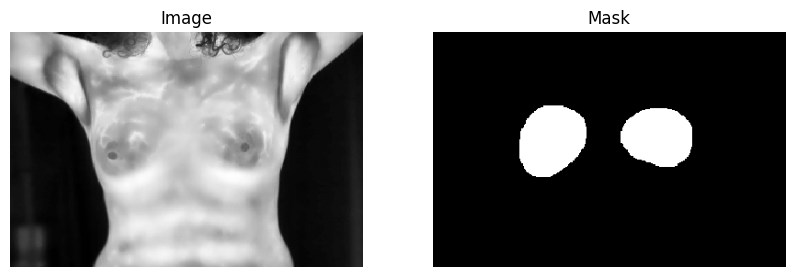

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


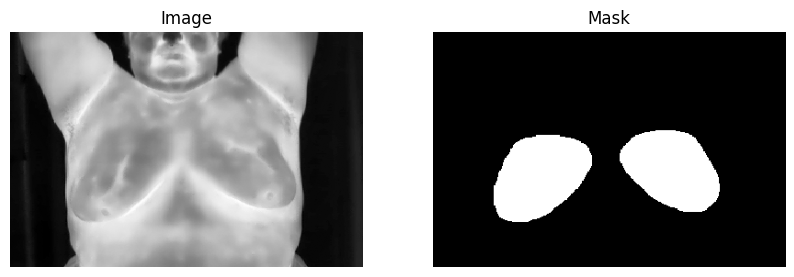

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


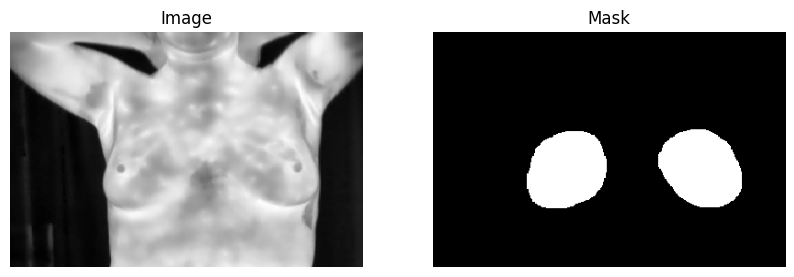

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


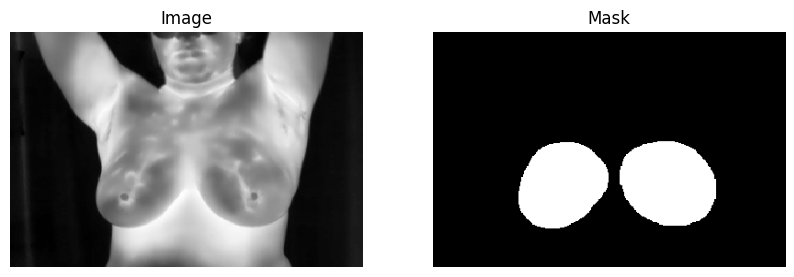

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


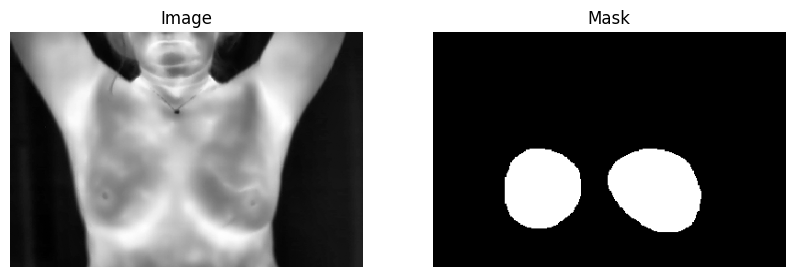

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


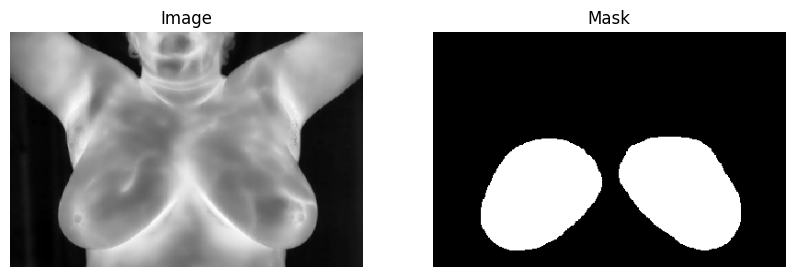

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


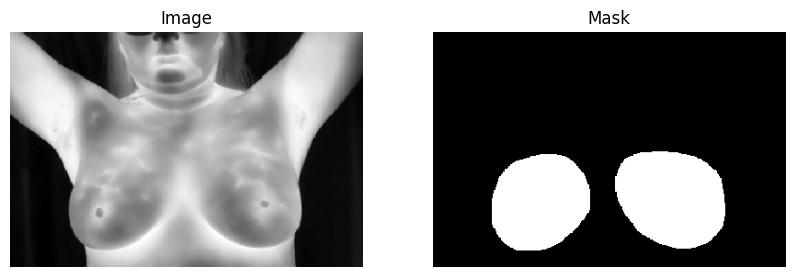

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


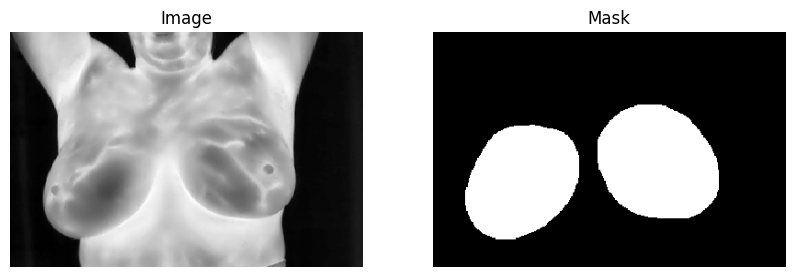

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


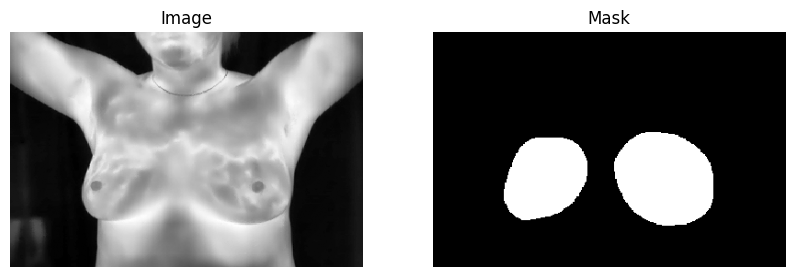

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


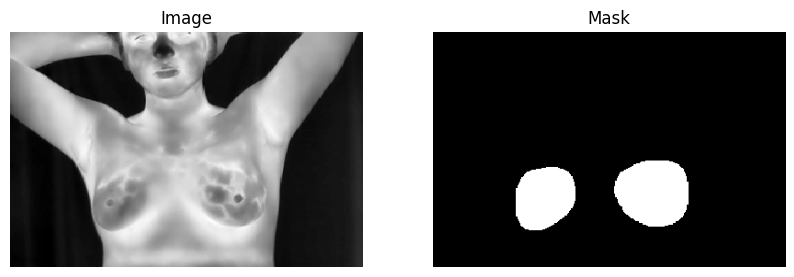

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


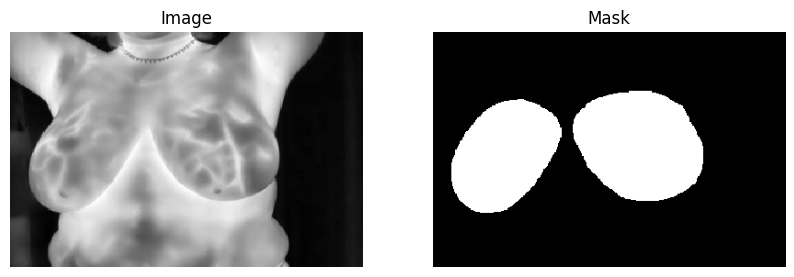

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


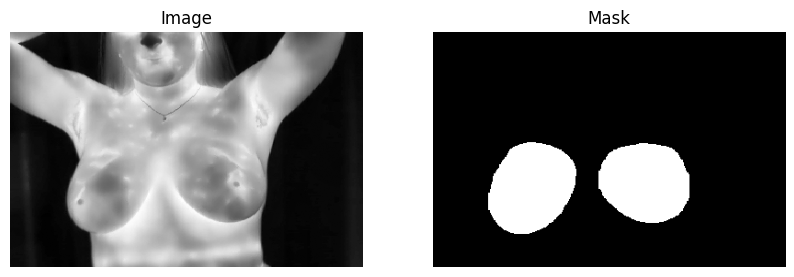

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


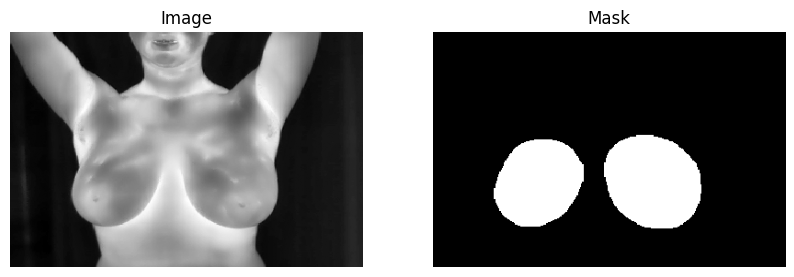

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


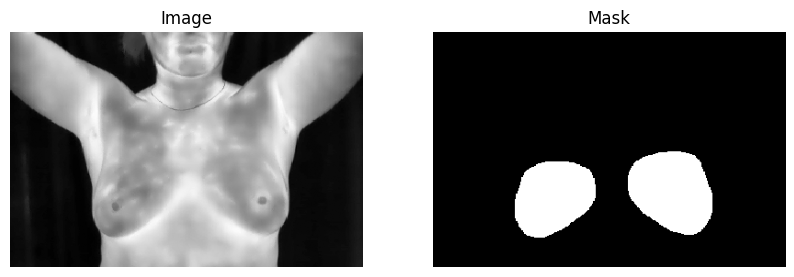

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


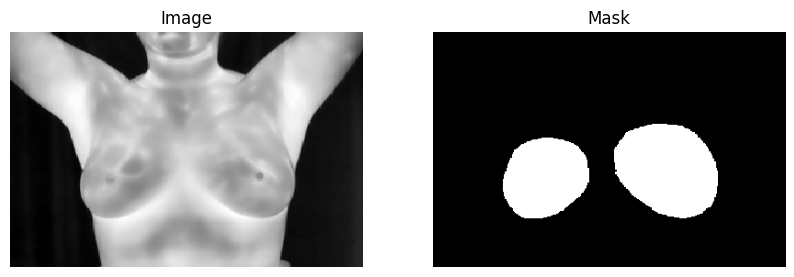

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  0.99607843
Mask unique values:  [0. 1.]


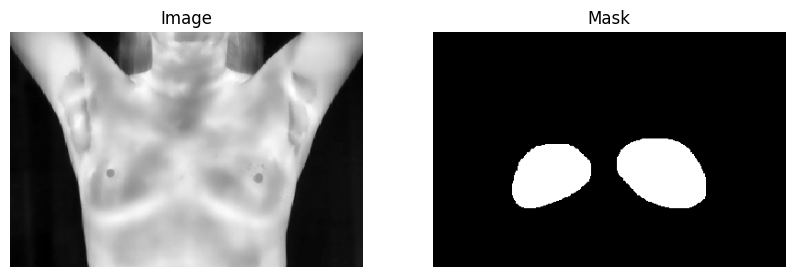

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


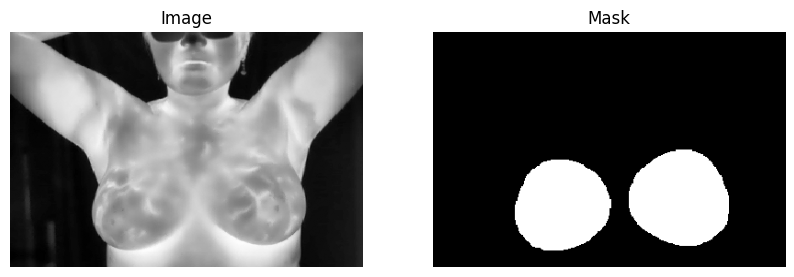

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


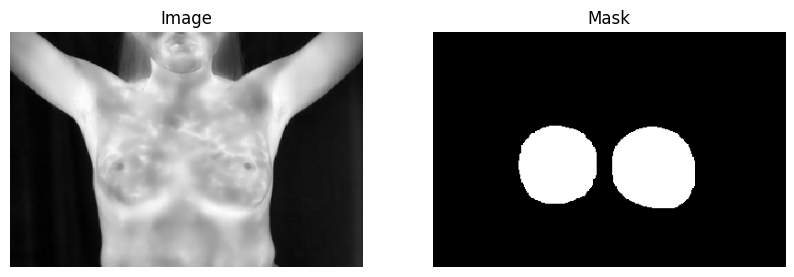

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


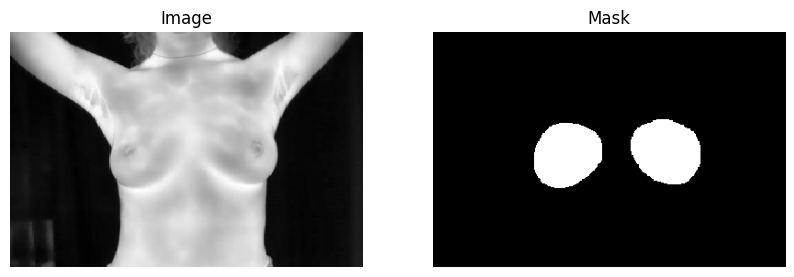

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


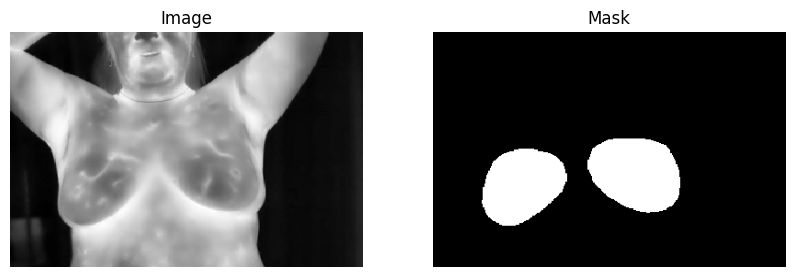

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


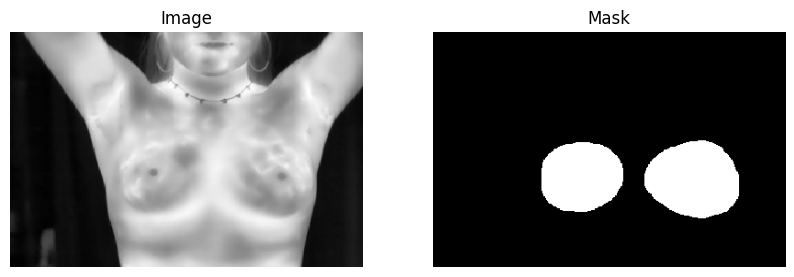

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


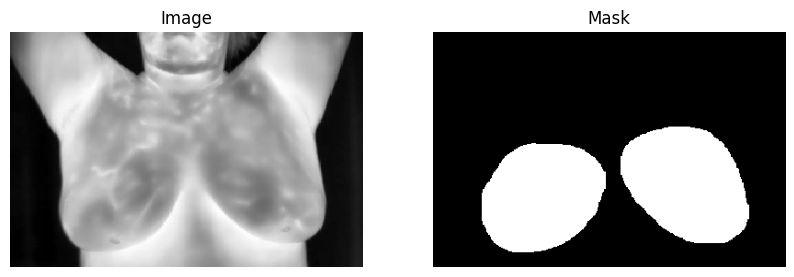

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.011764706
Image max:  1.0
Mask unique values:  [0. 1.]


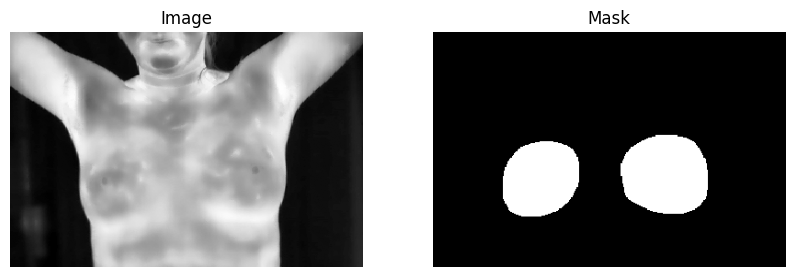

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  0.99607843
Mask unique values:  [0. 1.]


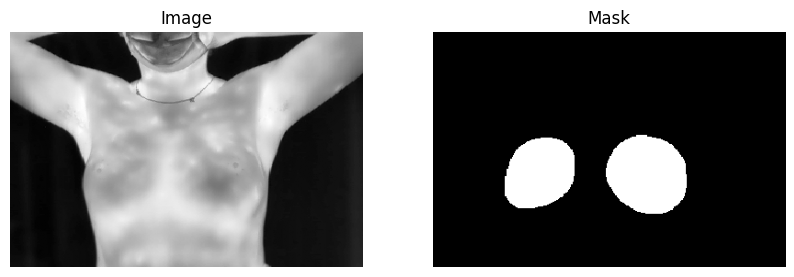

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


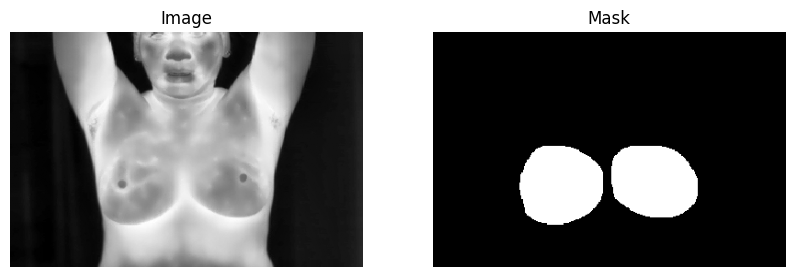

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


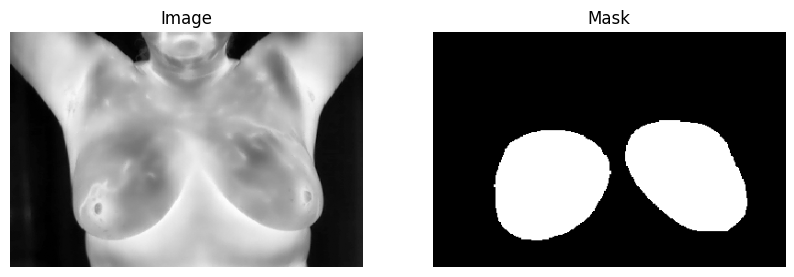

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


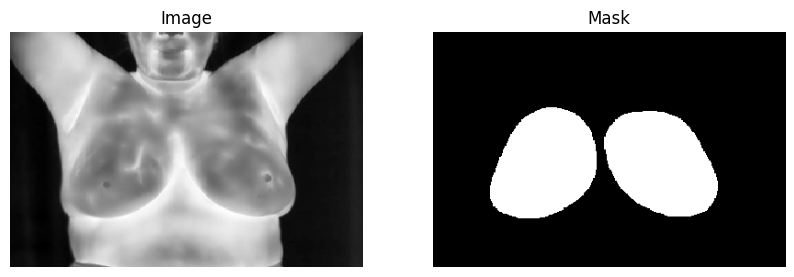

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


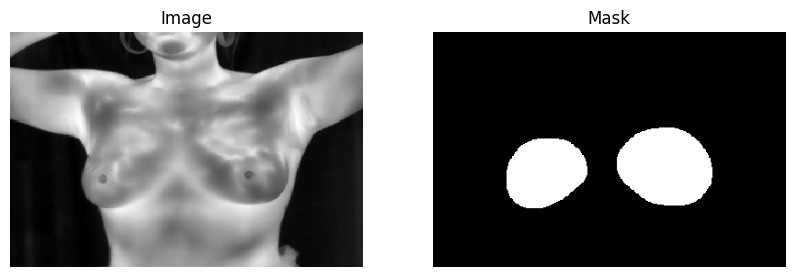

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


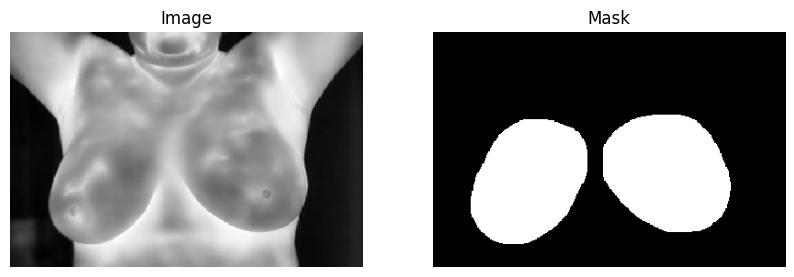

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


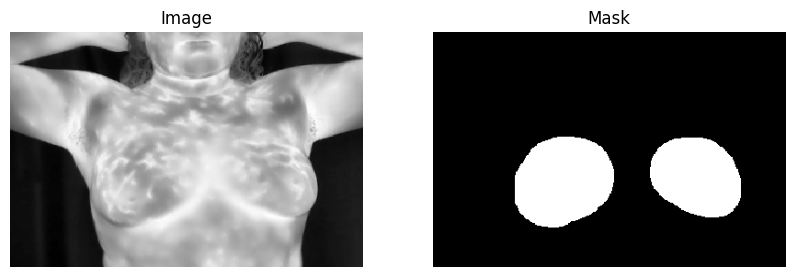

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  0.99607843
Mask unique values:  [0. 1.]


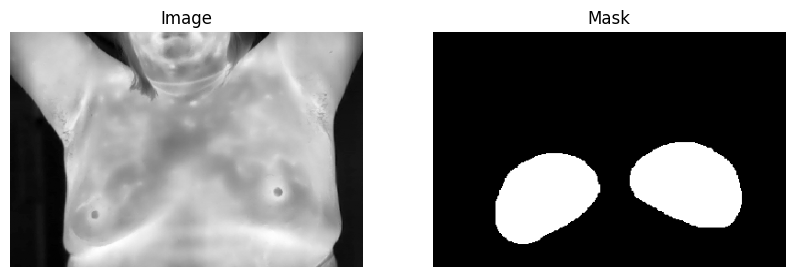

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.011764706
Image max:  1.0
Mask unique values:  [0. 1.]


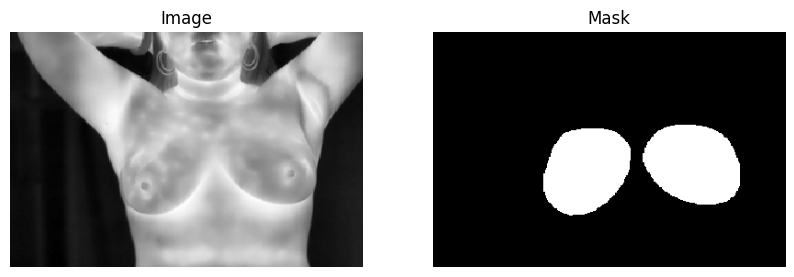

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


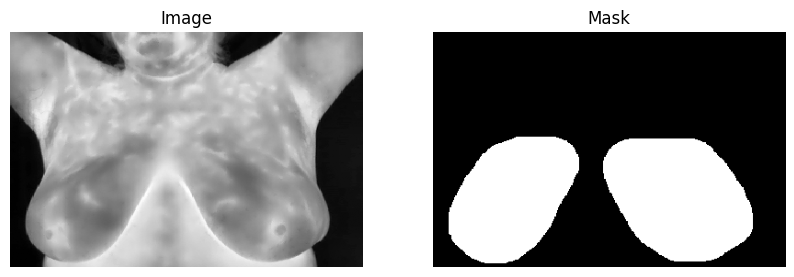

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


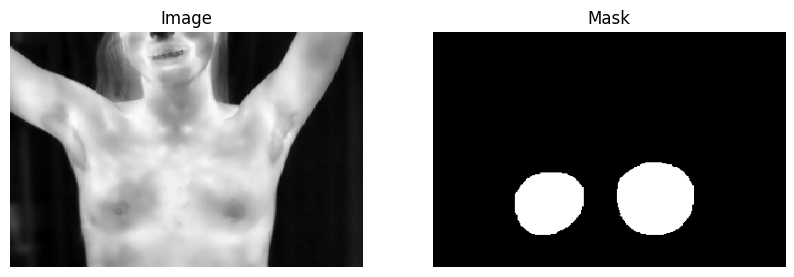

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


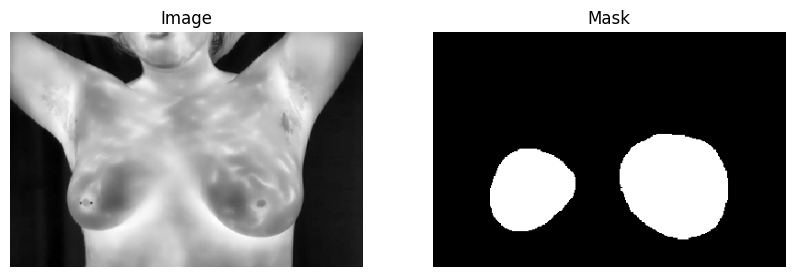

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


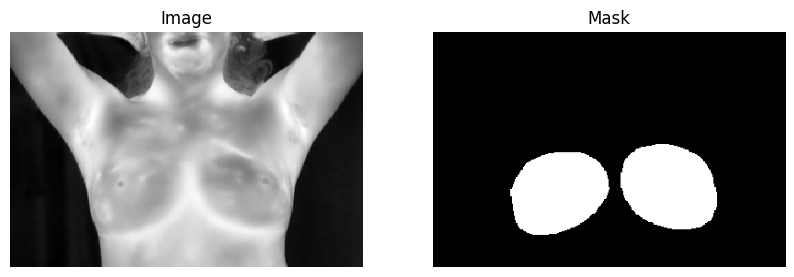

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


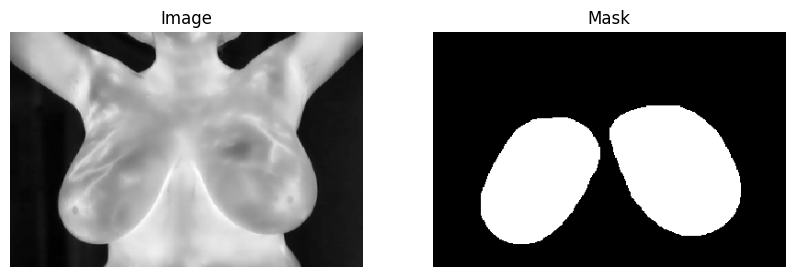

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


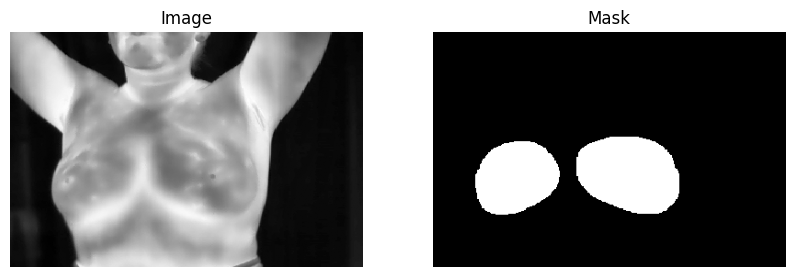

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


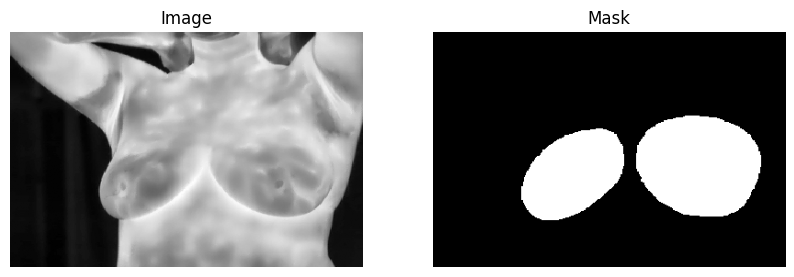

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  1.0
Mask unique values:  [0. 1.]


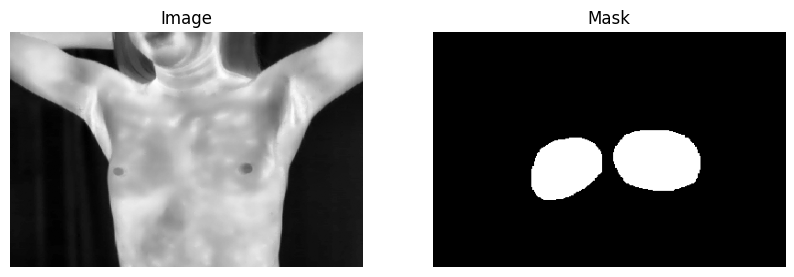

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


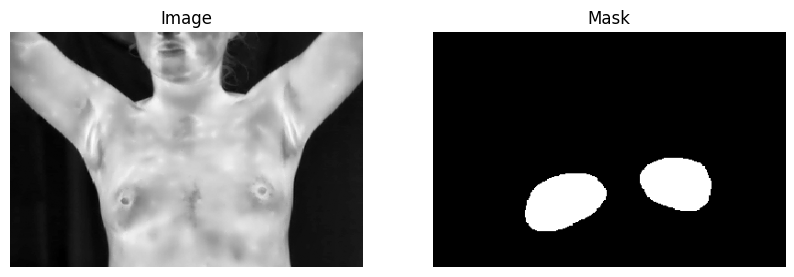

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


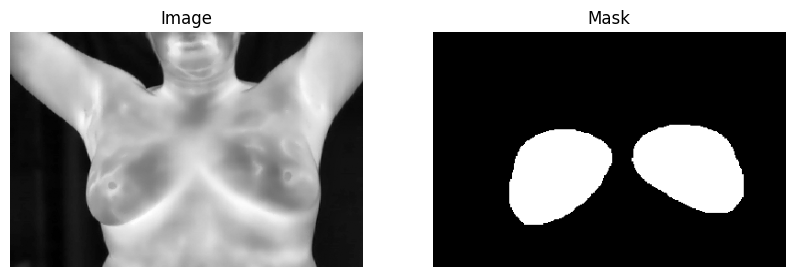

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


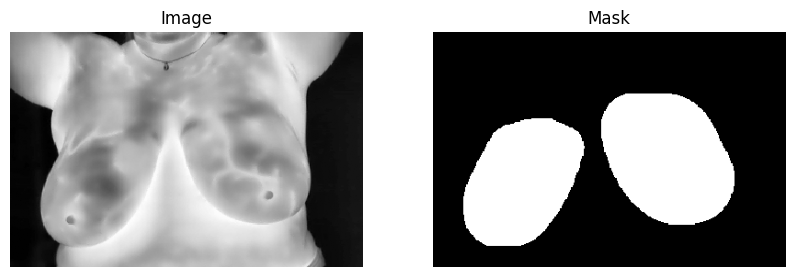

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.011764706
Image max:  1.0
Mask unique values:  [0. 1.]


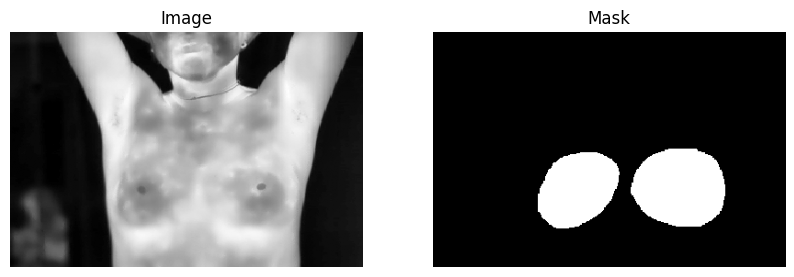

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.003921569
Image max:  0.99607843
Mask unique values:  [0. 1.]


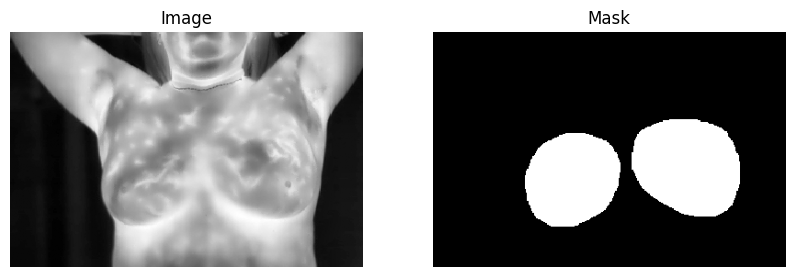

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  0.99607843
Mask unique values:  [0. 1.]


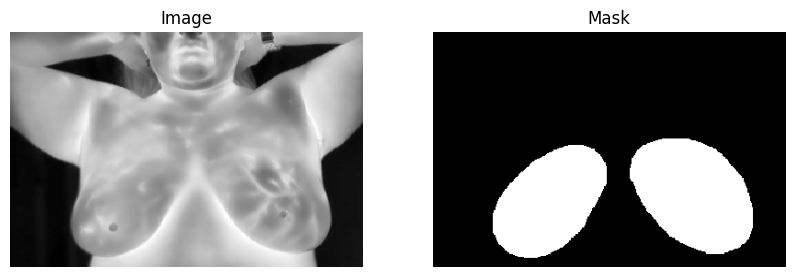

Image shape:  (256, 384)
Mask shape:  (256, 384)
Image min:  0.007843138
Image max:  1.0
Mask unique values:  [0. 1.]


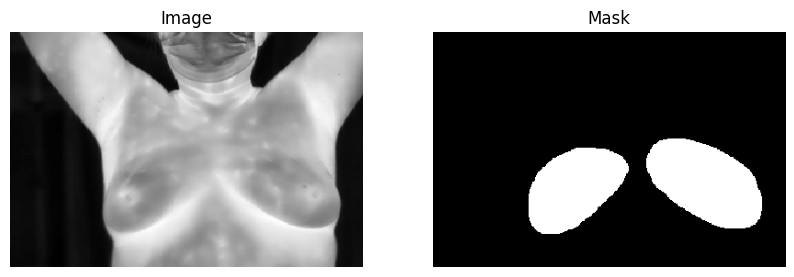

In [ ]:
indexes = random.sample(range(len(dataset)), 5)
print("Random indexes: ", indexes)

for i in indexes:
    image, mask = dataset[i]

    image = image.numpy()
    mask = mask.numpy()

    image = np.squeeze(image)
    mask = np.squeeze(mask)

    print("Image shape: ", image.shape)
    print("Mask shape: ", mask.shape)
    print("Image min: ", np.min(image))
    print("Image max: ", np.max(image))
    print("Mask unique values: ", np.unique(mask))
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Image")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')
    plt.show()